<a href="https://colab.research.google.com/github/RoshanSekar1106/AI-INTERNSHIP/blob/main/Restaurant_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df1=pd.read_csv('/content/i1.csv')
df2=pd.read_csv('/content/i2.csv')

In [ ]:
df=df1.merge(df2,how='outer')
df.shape

(15621, 16)

In [ ]:
df.isnull()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15616,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15617,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15618,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15619,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True


In [ ]:
df.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [ ]:
df.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [ ]:
df.tail()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
15616,2023-09-19,2023-09-19 22:03:44,28389,Kulcha,55.0,1.0,55.0,0.0,2.76,57.76,16.0,biller,0,NaN,Indian Breads,NaN
15617,2023-09-19,2023-09-19 22:03:44,28389,Mineral Water,20.0,2.0,40.0,0.0,2.00,42.00,16.0,biller,0,NaN,Deserts & Mocktails,NaN
15618,2023-09-19,2023-09-19 22:03:44,28389,Mushroom Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15619,2023-09-19,2023-09-19 22:03:44,28389,Paneer Butter Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15620,2023-09-19,2023-09-19 22:03:44,28389,Parota,30.0,4.0,120.0,0.0,6.00,126.00,16.0,biller,0,NaN,Indian Breads,NaN


In [ ]:
df=df.drop(['Table No.','Covers','Server Name','Variation','HSN'],axis=1)

In [ ]:

tot=df['Final Total'].sum()
print(tot)


2397010.12


In [ ]:
df['Invoice No.'].nunique()

4925

In [ ]:
from re import U
average=tot/U
print(average)

74906.56625


In [ ]:
a=df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name', ylabel='Qty.'>

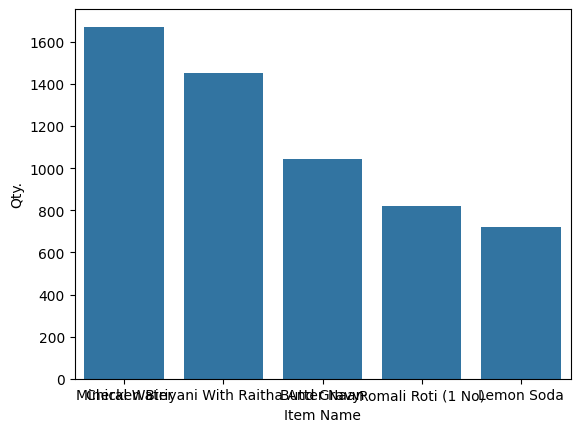

In [ ]:
sns.barplot(a)

Item Name
Chicken Biriyani With Raitha And Gravy    240730.96
Chicken Fried Rice                        119347.20
Butter Naan                                65387.74
Thandoor Chicken Half                      53185.83
Paneer Butter Masala                       49581.22
Name: Final Total, dtype: float64


<Axes: xlabel='Item Name', ylabel='Final Total'>

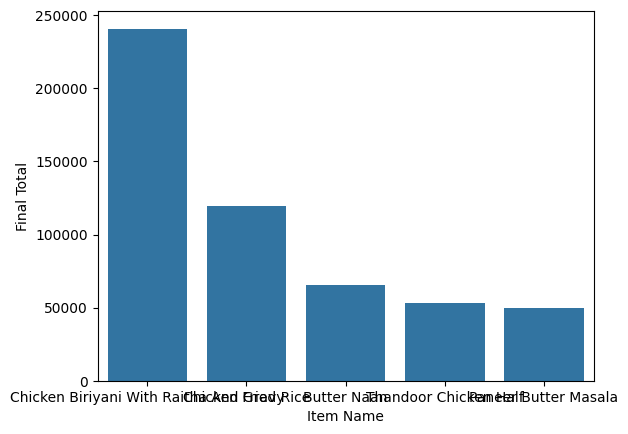

In [ ]:
b=df.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:5]
print(b)
sns.barplot(b)

In [ ]:
df.groupby('Date')['Final Total'].sum().loc["2023-09-15"]

np.float64(21042.02)

In [ ]:
totalChickennoodles= df.groupby(['Date','Item Name'])['Qty.'].sum().loc[('2023-09-15','Chicken Noodles')]
print(totalChickennoodles)

7.0


In [ ]:
invoicetot = df.groupby('Invoice No.')['Final Total'].sum()
invoice = invoicetot[invoicetot >2000]
print(invoice)

Invoice No.
23499     2533.64
23508     2011.00
23637     5644.82
23718     3517.50
23827    22638.00
           ...   
28014     3013.68
28126     2887.50
28145     4078.68
28259     4291.36
28315     2004.44
Name: Final Total, Length: 162, dtype: float64


In [ ]:
invoice=df[df['Final Total']==2887.50]['Invoice No.']
print(invoice)

14772    28126
Name: Invoice No., dtype: int64


In [ ]:
d=df[df['Invoice No.']==28145]['Final Total']
e=df[df['Invoice No.']==28145]['Qty.']
f=df[df['Invoice No.']==28145]['Item Name']
print('final total',d,"/n")
print(e)
print(f)

final total 14830    160.66
14831    160.66
14832    340.20
14833    302.40
14834    321.30
14835    160.66
14836    376.12
14837    340.20
14838    113.40
14839    141.76
14840    151.20
14841     75.60
14842    377.06
14843    197.50
14844    283.50
14845    302.40
14846    151.20
14847    122.86
Name: Final Total, dtype: float64 /n
14830    1.0
14831    1.0
14832    6.0
14833    2.0
14834    2.0
14835    1.0
14836    2.0
14837    6.0
14838    1.0
14839    1.0
14840    1.0
14841    4.0
14842    1.0
14843    1.0
14844    6.0
14845    2.0
14846    1.0
14847    1.0
Name: Qty., dtype: float64
14830                      Butter Chicken Gravy
14831                      Butter Chicken Gravy
14832                               Butter Naan
14833    Chicken Biriyani With Raitha And Gravy
14834                   Chicken Chettinad Gravy
14835                Chicken Pallipalayam Gravy
14836                                   Fish 65
14837                               Garlic Naan
14838             

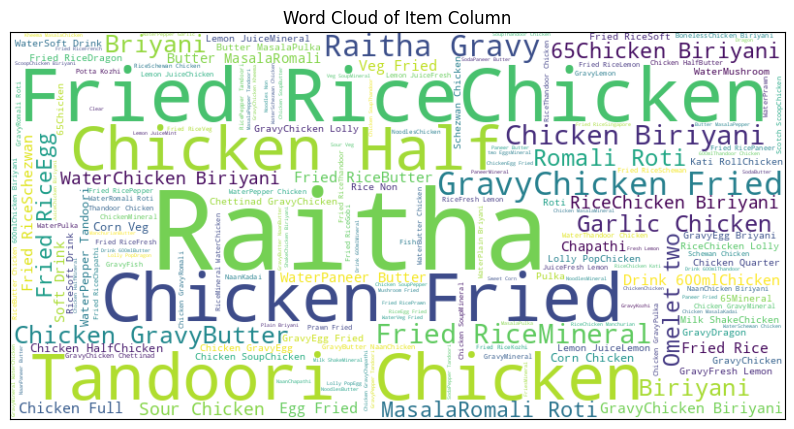

In [ ]:
from matplotlib.image import interpolations_names
from IPython.core.pylabtools import figsize
from wordcloud import WordCloud
text =''.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_title('Word Cloud of Item Column')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

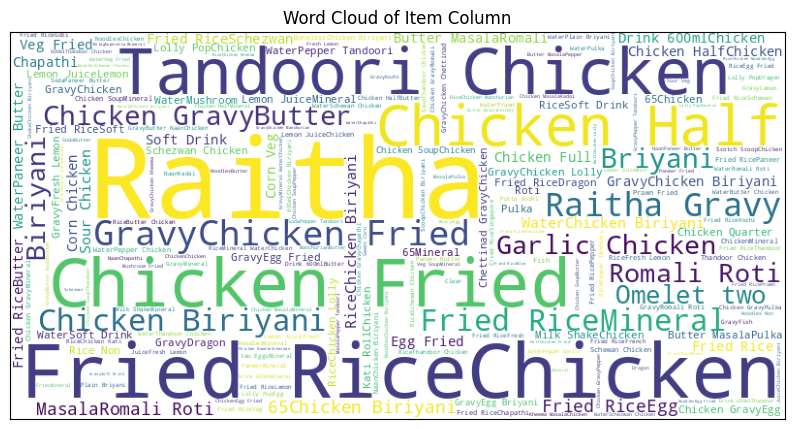

In [ ]:
from matplotlib.image import interpolations_names
from IPython.core.pylabtools import figsize
from wordcloud import WordCloud
text =''.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='antialiased')
ax.set_title('Word Cloud of Item Column')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

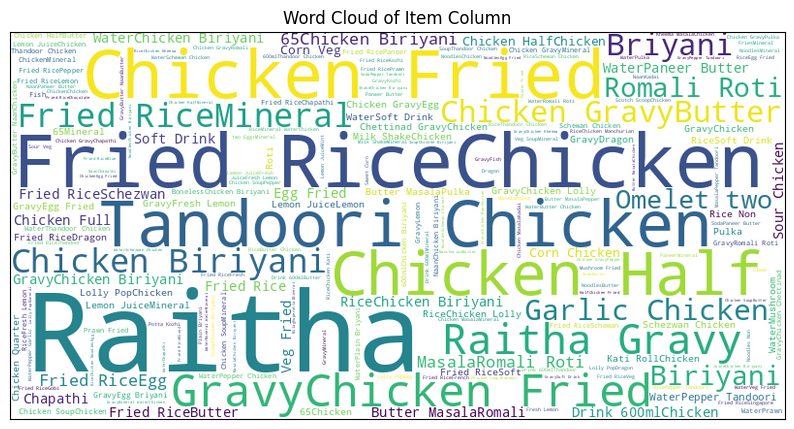

In [ ]:
from matplotlib.image import interpolations_names
from IPython.core.pylabtools import figsize
from wordcloud import WordCloud
text =''.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='spline36')
ax.set_title('Word Cloud of Item Column')
ax.set_xticks([])
ax.set_yticks([])
plt.show()